# 04 — Product Recommendation ML
**Merchant Network Analytics — Capstone Project BNI ODP**

---

## Tujuan
Memprediksi layanan pembayaran yang sesuai untuk setiap merchant:
- **Kelas 0: QRIS only** — merchant skala kecil, low-volume, entry-level
- **Kelas 1: Has EDC** — merchant skala menengah-besar, butuh terminal fisik

**Fokus:** Fee-based income dari layanan pembayaran (QRIS, EDC).
Bukan produk kredit atau simpanan.

**Training data:** Merchant BNI existing dengan produk yang sudah diketahui
**Prediksi:** Hanya merchant non-BNI (merchant BNI sudah punya produk existing) → untuk rekomendasi saat akuisisi

**Urutan notebook:**
01 EDA → 02 Graph → 03 Acquisition Scoring → **04 Product Rec** → 05 GenAI

**Input:** feature_table.csv, merchants_clean.csv
**Output:** product_rec_model.pkl, merchants_with_product_rec.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib, os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
import os
PROJECT_ROOT = '.' if os.path.isdir('./data') else '..'

feature_table   = pd.read_csv(f'{PROJECT_ROOT}/data/processed/feature_table.csv')
merchants_clean = pd.read_csv(f'{PROJECT_ROOT}/data/processed/merchants_clean.csv')

print(f"Feature table  : {feature_table.shape}")
print(f"Merchants      : {len(merchants_clean)}")

Feature table  : (656, 34)
Merchants      : 656


## 1. Eksplorasi Distribusi Produk BNI

Sebelum training, lihat distribusi produk pada merchant yang sudah nasabah BNI.
Ini menentukan feasibility binary classification.

In [2]:
# Merchant BNI existing dengan produk yang diketahui
bni_merchants = merchants_clean[
    (merchants_clean['is_nasabah_bni'] == 'Ya') &
    (merchants_clean['produk_bni'].notna())
].copy()

print(f"=== Distribusi Produk BNI ===")
print(f"Total merchant BNI dengan produk: {len(bni_merchants)}")
print()
print(bni_merchants['produk_bni'].value_counts())
print()

# Konstruksi binary label
# Kelas 0: QRIS only
# Kelas 1: Has EDC (EDC saja atau EDC+QRIS)
def assign_product_label(produk):
    if pd.isna(produk):
        return None
    produk_str = str(produk).upper()
    if 'EDC' in produk_str:
        return 1  # Has EDC
    elif 'QRIS' in produk_str:
        return 0  # QRIS only
    else:
        return None  # Tidak relevan (e.g. hanya Giro jika masih ada)

bni_merchants['product_label'] = bni_merchants['produk_bni'].apply(assign_product_label)

# Drop yang tidak bisa dilabeli
bni_merchants = bni_merchants.dropna(subset=['product_label'])
bni_merchants['product_label'] = bni_merchants['product_label'].astype(int)

print(f"\n=== Binary Label Distribution ===")
label_counts = bni_merchants['product_label'].value_counts()
print(f"Kelas 0 (QRIS only): {label_counts.get(0, 0)} merchant ({label_counts.get(0,0)/len(bni_merchants)*100:.1f}%)")
print(f"Kelas 1 (Has EDC)  : {label_counts.get(1, 0)} merchant ({label_counts.get(1,0)/len(bni_merchants)*100:.1f}%)")
print(f"Total training data: {len(bni_merchants)}")
print(f"\nImbalance ratio: {label_counts.max()/label_counts.min():.1f}:1")

=== Distribusi Produk BNI ===
Total merchant BNI dengan produk: 435

produk_bni
EDC, QRIS    151
EDC          144
QRIS         140
Name: count, dtype: int64


=== Binary Label Distribution ===
Kelas 0 (QRIS only): 140 merchant (32.2%)
Kelas 1 (Has EDC)  : 295 merchant (67.8%)
Total training data: 435

Imbalance ratio: 2.1:1


## 2. Gabung dengan Graph Features & Seleksi Fitur

Untuk product recommendation, SEMUA graph features bisa digunakan sebagai fitur
karena target (produk_bni) adalah informasi independen dari graph metrics.
Tidak ada leakage seperti di notebook 03.

Fitur yang digunakan:
- Merchant attributes: omzet, kategori, kota
- Graph metrics: degree, pagerank, betweenness, connected_bni_ratio, dll
- Profile: lama beroperasi, karyawan, outlet, rating

In [3]:
# Gabung BNI merchants dengan graph features
training_df = bni_merchants[['merchant_id', 'product_label']].merge(
    feature_table, on='merchant_id', how='left'
)

print(f"Training set setelah merge: {len(training_df)} rows")
print(f"Missing values: {training_df.isnull().sum().sum()}")

# Feature columns untuk product recommendation
# Semua fitur relevan (tidak ada leakage karena target berbeda)
PROD_FEATURE_COLS = [
    # Merchant attributes
    'avg_omzet_bulanan', 'log_omzet', 'kategori', 'kota',
    
    # Graph metrics (SEMUA bisa digunakan)
    'degree', 'weighted_degree', 'log_weighted_degree',
    'pagerank', 'log_pagerank',
    'betweenness', 'community_size', 'community_id',
    'connected_bni_ratio', 'avg_neighbor_jaccard',
    'n_customers', 'log_n_customers',
    'is_hub', 'customer_density',
    
    # Profile
    'lama_beroperasi_tahun', 'jumlah_karyawan', 'rating_google',
    'jumlah_outlet', 'has_rating', 'has_website', 'has_social_media',
]

# Filter hanya yang ada
PROD_FEATURE_COLS = [c for c in PROD_FEATURE_COLS if c in training_df.columns]
print(f"\nJumlah fitur: {len(PROD_FEATURE_COLS)}")

# Encode categorical
prod_label_encoders = {}
for col in ['kategori', 'kota']:
    if col in training_df.columns:
        le = LabelEncoder()
        training_df[col] = le.fit_transform(training_df[col].astype(str))
        prod_label_encoders[col] = le
        print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

training_df = training_df.fillna(0)

X_prod = training_df[PROD_FEATURE_COLS]
y_prod = training_df['product_label']

print(f"\nShape X: {X_prod.shape}")
print(f"Label distribution: {y_prod.value_counts().to_dict()}")

Training set setelah merge: 435 rows
Missing values: 0

Jumlah fitur: 25
Encoded kategori: {'Automotive': np.int64(0), 'Electronics': np.int64(1), 'F&B': np.int64(2), 'Fashion': np.int64(3), 'Grocery': np.int64(4)}
Encoded kota: {'Bandung': np.int64(0), 'Bekasi': np.int64(1), 'Bogor': np.int64(2), 'Depok': np.int64(3), 'Jakarta': np.int64(4), 'Tangerang': np.int64(5)}

Shape X: (435, 25)
Label distribution: {1: 295, 0: 140}


In [4]:
X_prod_train, X_prod_test, y_prod_train, y_prod_test = train_test_split(
    X_prod, y_prod, test_size=0.2, random_state=42, stratify=y_prod
)

print(f"Train: {X_prod_train.shape} | Label 0: {(y_prod_train==0).sum()} | Label 1: {(y_prod_train==1).sum()}")
print(f"Test : {X_prod_test.shape} | Label 0: {(y_prod_test==0).sum()} | Label 1: {(y_prod_test==1).sum()}")

Train: (348, 25) | Label 0: 112 | Label 1: 236
Test : (87, 25) | Label 0: 28 | Label 1: 59


In [5]:
# Cek ratio imbalance
ratio = y_prod_train.value_counts().max() / y_prod_train.value_counts().min()
print(f"Imbalance ratio training: {ratio:.1f}:1")

# Apply SMOTE jika ratio > 2:1
if ratio > 2.0:
    smote = SMOTE(random_state=42)
    X_prod_train_smote, y_prod_train_smote = smote.fit_resample(X_prod_train, y_prod_train)
    print(f"SMOTE applied:")
    print(f"  Sebelum: {len(y_prod_train)} (0:{(y_prod_train==0).sum()}, 1:{(y_prod_train==1).sum()})")
    print(f"  Sesudah: {len(y_prod_train_smote)} (0:{(y_prod_train_smote==0).sum()}, 1:{(y_prod_train_smote==1).sum()})")
    use_smote = True
else:
    X_prod_train_smote = X_prod_train.copy()
    y_prod_train_smote = y_prod_train.copy()
    print("SMOTE tidak diperlukan (ratio < 2:1)")
    use_smote = False

Imbalance ratio training: 2.1:1
SMOTE applied:
  Sebelum: 348 (0:112, 1:236)
  Sesudah: 472 (0:236, 1:236)


## 3. Baseline Models

In [6]:
prod_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42),
}

prod_results = []
print("=" * 70)
print("PRODUCT RECOMMENDATION — BASELINE MODELS")
print("=" * 70)

for name, model in prod_models.items():
    model.fit(X_prod_train_smote, y_prod_train_smote)
    y_pred = model.predict(X_prod_test)
    y_proba = model.predict_proba(X_prod_test)[:, 1]

    acc  = accuracy_score(y_prod_test, y_pred)
    prec = precision_score(y_prod_test, y_pred, zero_division=0)
    rec  = recall_score(y_prod_test, y_pred, zero_division=0)
    f1   = f1_score(y_prod_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_prod_test, y_proba)

    prod_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1': f1, 'AUC-ROC': auc})

    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    print(f"  F1: {f1:.4f} | AUC-ROC: {auc:.4f}")

df_prod_results = pd.DataFrame(prod_results)
print(f"\n=== PERBANDINGAN ===")
print(df_prod_results.round(4).to_string(index=False))

PRODUCT RECOMMENDATION — BASELINE MODELS

Logistic Regression:
  Accuracy: 0.6782 | Precision: 0.6782 | Recall: 1.0000
  F1: 0.8082 | AUC-ROC: 0.4576

Decision Tree:
  Accuracy: 0.7011 | Precision: 0.7619 | Recall: 0.8136
  F1: 0.7869 | AUC-ROC: 0.6389

Random Forest:
  Accuracy: 0.6437 | Precision: 0.7000 | Recall: 0.8305
  F1: 0.7597 | AUC-ROC: 0.5657

XGBoost:
  Accuracy: 0.6437 | Precision: 0.7121 | Recall: 0.7966
  F1: 0.7520 | AUC-ROC: 0.5139

=== PERBANDINGAN ===
              Model  Accuracy  Precision  Recall     F1  AUC-ROC
Logistic Regression    0.6782     0.6782  1.0000 0.8082   0.4576
      Decision Tree    0.7011     0.7619  0.8136 0.7869   0.6389
      Random Forest    0.6437     0.7000  0.8305 0.7597   0.5657
            XGBoost    0.6437     0.7121  0.7966 0.7520   0.5139


In [7]:
best_prod_name = df_prod_results.loc[df_prod_results['F1'].idxmax(), 'Model']
best_auc = df_prod_results.loc[df_prod_results['F1'].idxmax(), 'AUC-ROC']

print(f"Model terpilih awal: {best_prod_name} (F1: {df_prod_results['F1'].max():.4f}, AUC: {best_auc:.4f})")

# Logistic Regression dengan AUC mendekati 0.5 = tidak lebih baik dari random
# Dalam kondisi ini, pilih model tree-based terbaik sebagai fallback
TREE_MODELS = ['Random Forest', 'XGBoost', 'Decision Tree']
if best_prod_name == 'Logistic Regression' and best_auc < 0.55:
    print(f"\n⚠️  {best_prod_name} AUC={best_auc:.4f} mendekati random classifier.")
    print("   Memilih model tree-based terbaik sebagai pengganti...")
    tree_results = df_prod_results[df_prod_results['Model'].isin(TREE_MODELS)]
    best_prod_name = tree_results.loc[tree_results['AUC-ROC'].idxmax(), 'Model']
    print(f"   → Model pengganti: {best_prod_name}")

print(f"\nModel final untuk tuning: {best_prod_name}")

param_grids_prod = {
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.05, 0.1],
            'min_child_weight': [1, 3],
            'subsample': [0.8, 1.0],
        },
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
        },
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        },
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=3000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs', 'liblinear'],
        },
    },
}

# Tune the model that actually won the baseline comparison (after fallback).
config = param_grids_prod[best_prod_name]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_prod = GridSearchCV(
    estimator=config['model'],
    param_grid=config['params'],
    cv=cv, scoring='f1', n_jobs=-1, verbose=1, refit=True,
)
grid_search_prod.fit(X_prod_train_smote, y_prod_train_smote)

print(f"Best CV F1: {grid_search_prod.best_score_:.4f}")
print(f"Best params: {grid_search_prod.best_params_}")

Model terpilih awal: Logistic Regression (F1: 0.8082, AUC: 0.4576)

⚠️  Logistic Regression AUC=0.4576 mendekati random classifier.
   Memilih model tree-based terbaik sebagai pengganti...
   → Model pengganti: Decision Tree

Model final untuk tuning: Decision Tree
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV F1: 0.6470
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


PRODUCT RECOMMENDATION — FINAL: Decision Tree
Accuracy : 0.7011
Precision: 0.7619
Recall   : 0.8136
F1       : 0.7869
AUC-ROC  : 0.6389

              precision    recall  f1-score   support

   QRIS Only       0.54      0.46      0.50        28
     Has EDC       0.76      0.81      0.79        59

    accuracy                           0.70        87
   macro avg       0.65      0.64      0.64        87
weighted avg       0.69      0.70      0.69        87



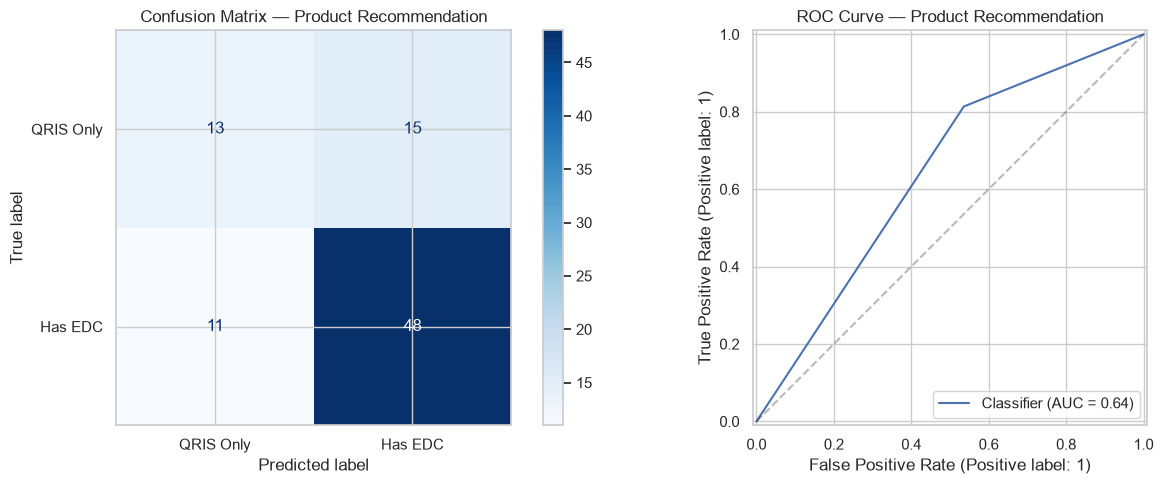

In [10]:
best_prod_model = grid_search_prod.best_estimator_
y_pred_prod = best_prod_model.predict(X_prod_test)
y_proba_prod = best_prod_model.predict_proba(X_prod_test)[:, 1]

print("=" * 60)
print(f"PRODUCT RECOMMENDATION — FINAL: {best_prod_name}")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_prod_test, y_pred_prod):.4f}")
print(f"Precision: {precision_score(y_prod_test, y_pred_prod):.4f}")
print(f"Recall   : {recall_score(y_prod_test, y_pred_prod):.4f}")
print(f"F1       : {f1_score(y_prod_test, y_pred_prod):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_prod_test, y_proba_prod):.4f}")
print()
print(classification_report(y_prod_test, y_pred_prod,
                             target_names=['QRIS Only', 'Has EDC']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_prod_test, y_pred_prod,
    display_labels=['QRIS Only', 'Has EDC'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — Product Recommendation')

RocCurveDisplay.from_predictions(y_prod_test, y_proba_prod, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curve — Product Recommendation')

plt.tight_layout()
os.makedirs(f'{PROJECT_ROOT}/notebooks/plots', exist_ok=True)
plt.savefig(f'{PROJECT_ROOT}/notebooks/plots/19_product_rec_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

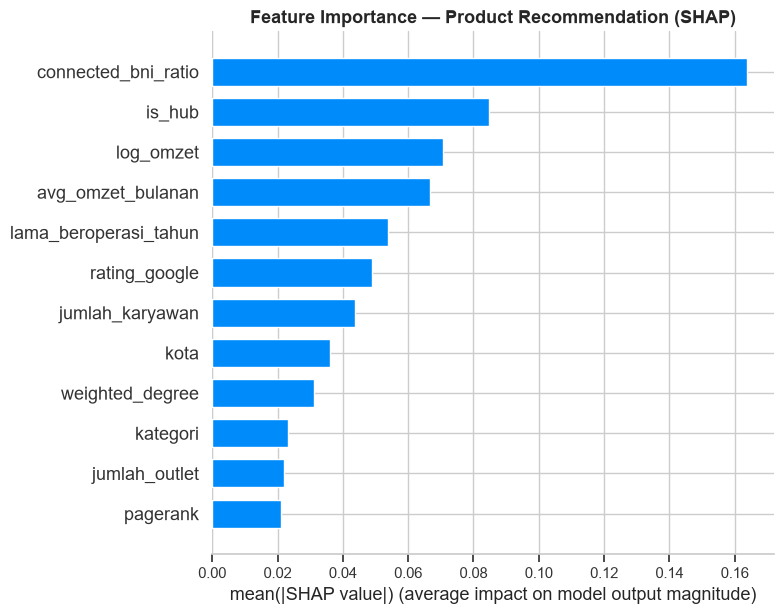

In [11]:
import shap

# Use an explainer compatible with the selected estimator family.
if isinstance(best_prod_model, LogisticRegression):
    prod_explainer = shap.LinearExplainer(best_prod_model, X_prod_train_smote)
else:
    prod_explainer = shap.TreeExplainer(best_prod_model)

prod_shap_raw = prod_explainer.shap_values(X_prod_test)

if isinstance(prod_shap_raw, list):
    prod_shap = prod_shap_raw[1]
elif getattr(prod_shap_raw, 'ndim', 0) == 3:
    prod_shap = prod_shap_raw[:, :, 1]
else:
    prod_shap = prod_shap_raw

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(prod_shap, X_prod_test, feature_names=PROD_FEATURE_COLS,
                  plot_type='bar', show=False, max_display=12)
plt.title('Feature Importance — Product Recommendation (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/notebooks/plots/20_product_rec_shap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Prediksi untuk Merchant Non-BNI

Model dilatih dari merchant BNI existing.
Sekarang prediksi hanya untuk merchant yang BELUM nasabah BNI —
merchant BNI existing sudah punya produk sendiri sehingga tidak perlu diprediksi —
untuk menghasilkan rekomendasi layanan saat akuisisi.

In [12]:
# Prediksi hanya untuk merchant yang BELUM nasabah BNI
# Merchant BNI sudah diketahui produknya dari data existing
non_bni_merchants = feature_table[
    feature_table['is_nasabah_bni'] == 'Tidak'
].copy()

print(f"Non-BNI merchant yang akan diprediksi: {len(non_bni_merchants)}")
print(f"BNI merchant (tidak diprediksi, produk sudah diketahui): "
      f"{(feature_table['is_nasabah_bni'] == 'Ya').sum()}")

# Encode categorical dengan encoder yang sama dari training
non_bni_encoded = non_bni_merchants.copy()
for col, le in prod_label_encoders.items():
    if col in non_bni_encoded.columns:
        non_bni_encoded[col] = non_bni_encoded[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )

X_pred_nonbni = non_bni_encoded[PROD_FEATURE_COLS].fillna(0)

# Prediksi
non_bni_merchants = non_bni_merchants.copy()
non_bni_merchants['product_rec_class'] = best_prod_model.predict(X_pred_nonbni)
non_bni_merchants['product_rec_proba_edc'] = best_prod_model.predict_proba(X_pred_nonbni)[:, 1]
non_bni_merchants['product_rec_source'] = 'ml_model'

# Mapping label ke nama produk
non_bni_merchants['product_recommendation'] = non_bni_merchants['product_rec_class'].map({
    0: 'QRIS',
    1: 'QRIS + EDC'
})

print(f"\n=== Distribusi Rekomendasi Produk (Non-BNI) ===")
print(non_bni_merchants['product_recommendation'].value_counts())
print(f"\nTop 10 Non-BNI direkomendasikan EDC (by proba):")
top_edc = non_bni_merchants[
    non_bni_merchants['product_rec_class'] == 1
].nlargest(10, 'product_rec_proba_edc')

if len(top_edc) > 0:
    print(top_edc[['merchant_id', 'nama', 'kategori', 'kota',
                    'product_recommendation', 'product_rec_proba_edc']].to_string())
else:
    print("Tidak ada merchant non-BNI yang direkomendasikan EDC")
    print("Cek model — kemungkinan masih memprediksi semua sebagai kelas 1")

Non-BNI merchant yang akan diprediksi: 221
BNI merchant (tidak diprediksi, produk sudah diketahui): 435

=== Distribusi Rekomendasi Produk (Non-BNI) ===
product_recommendation
QRIS + EDC    146
QRIS           75
Name: count, dtype: int64

Top 10 Non-BNI direkomendasikan EDC (by proba):
    merchant_id                      nama    kategori       kota product_recommendation  product_rec_proba_edc
436       M0049       UD Supplier Lestari         F&B    Bandung             QRIS + EDC                    1.0
438       M0682               Motor Surya  Automotive      Depok             QRIS + EDC                    1.0
439       M0684          Bengkel Mbak Sri  Automotive    Jakarta             QRIS + EDC                    1.0
440       M0685    Toko Sparepart Lestari  Automotive     Bekasi             QRIS + EDC                    1.0
441       M0687            Motor Pak Haji  Automotive  Tangerang             QRIS + EDC                    1.0
444       M0680               Motor Citra  Auto

In [13]:
# === DIAGNOSTIC: Cek apakah ada masalah prediksi ===
qris_count = (non_bni_merchants['product_rec_class'] == 0).sum()
edc_count  = (non_bni_merchants['product_rec_class'] == 1).sum()

print(f"=== DIAGNOSTIC CHECK ===")
print(f"QRIS only  : {qris_count} ({qris_count/len(non_bni_merchants)*100:.1f}%)")
print(f"QRIS + EDC : {edc_count} ({edc_count/len(non_bni_merchants)*100:.1f}%)")

if qris_count == 0:
    print("\n⚠️  WARNING: Model memprediksi SEMUA sebagai QRIS+EDC!")
    print("   Kemungkinan model masih bias ke kelas mayoritas.")
    print("   Pertimbangkan untuk menggunakan threshold yang berbeda.")

    # Fallback: gunakan threshold 0.6 bukan 0.5
    non_bni_merchants['product_rec_class_adj'] = (
        non_bni_merchants['product_rec_proba_edc'] >= 0.6
    ).astype(int)
    non_bni_merchants['product_recommendation'] = non_bni_merchants['product_rec_class_adj'].map({
        0: 'QRIS', 1: 'QRIS + EDC'
    })
    non_bni_merchants['product_rec_class'] = non_bni_merchants['product_rec_class_adj']
    print(f"\n   Setelah threshold 0.6:")
    print(f"   QRIS only  : {(non_bni_merchants['product_rec_class']==0).sum()}")
    print(f"   QRIS + EDC : {(non_bni_merchants['product_rec_class']==1).sum()}")
elif edc_count == 0:
    print("\n⚠️  WARNING: Model memprediksi SEMUA sebagai QRIS only!")
    # Fallback: threshold 0.4
    non_bni_merchants['product_rec_class_adj'] = (
        non_bni_merchants['product_rec_proba_edc'] >= 0.4
    ).astype(int)
    non_bni_merchants['product_recommendation'] = non_bni_merchants['product_rec_class_adj'].map({
        0: 'QRIS', 1: 'QRIS + EDC'
    })
    non_bni_merchants['product_rec_class'] = non_bni_merchants['product_rec_class_adj']
    print(f"\n   Setelah threshold 0.4:")
    print(f"   QRIS only  : {(non_bni_merchants['product_rec_class']==0).sum()}")
    print(f"   QRIS + EDC : {(non_bni_merchants['product_rec_class']==1).sum()}")
else:
    print("\n✓ Distribusi prediksi normal")

=== DIAGNOSTIC CHECK ===
QRIS only  : 75 (33.9%)
QRIS + EDC : 146 (66.1%)

✓ Distribusi prediksi normal


In [14]:
# Save model
joblib.dump(best_prod_model, f'{PROJECT_ROOT}/models/product_rec_model.pkl')
print("Saved: product_rec_model.pkl")

joblib.dump(prod_label_encoders, f'{PROJECT_ROOT}/models/product_rec_label_encoders.pkl')
print("Saved: product_rec_label_encoders.pkl")

joblib.dump(PROD_FEATURE_COLS, f'{PROJECT_ROOT}/models/product_rec_feature_cols.pkl')
print("Saved: product_rec_feature_cols.pkl")

prod_metadata = {
    'model_name'  : best_prod_name,
    'best_params' : grid_search_prod.best_params_,
    'best_cv_f1'  : grid_search_prod.best_score_,
    'use_smote'   : use_smote,
    'label_map'   : {0: 'QRIS', 1: 'QRIS + EDC'},
    'training_samples': len(y_prod),
    'test_metrics': {
        'accuracy' : accuracy_score(y_prod_test, y_pred_prod),
        'precision': precision_score(y_prod_test, y_pred_prod),
        'recall'   : recall_score(y_prod_test, y_pred_prod),
        'f1'       : f1_score(y_prod_test, y_pred_prod),
        'auc_roc'  : roc_auc_score(y_prod_test, y_proba_prod),
    }
}
joblib.dump(prod_metadata, f'{PROJECT_ROOT}/models/product_rec_metadata.pkl')
print("Saved: product_rec_metadata.pkl")

# Load merchants_with_predictions dari notebook 03 (priority scores)
try:
    acq_predictions = pd.read_csv(
        f'{PROJECT_ROOT}/data/processed/merchants_with_predictions.csv'
    )
    print(f"Loaded merchants_with_predictions.csv: {len(acq_predictions)} rows")
except FileNotFoundError:
    print("ERROR: merchants_with_predictions.csv tidak ditemukan")
    print("Jalankan notebook 03 terlebih dahulu")
    raise

# Kolom product recommendation untuk non-BNI
prod_cols = ['merchant_id', 'product_recommendation', 'product_rec_class',
             'product_rec_proba_edc', 'product_rec_source']

# Merge: tambahkan product recommendation ke acquisition predictions
merged = acq_predictions.merge(
    non_bni_merchants[prod_cols],
    on='merchant_id',
    how='left'
)

# Untuk merchant BNI: isi product_recommendation dengan produk existing mereka
bni_produk = acq_predictions[
    acq_predictions['is_nasabah_bni'] == 'Ya'
][['merchant_id', 'produk_bni']].copy()

for idx, row in bni_produk.iterrows():
    mid = row['merchant_id']
    produk = row['produk_bni']
    if pd.notna(produk):
        mask = merged['merchant_id'] == mid
        if 'EDC' in str(produk).upper():
            merged.loc[mask, 'product_recommendation'] = 'QRIS + EDC'
            merged.loc[mask, 'product_rec_source'] = 'existing_bni'
        elif 'QRIS' in str(produk).upper():
            merged.loc[mask, 'product_recommendation'] = 'QRIS'
            merged.loc[mask, 'product_rec_source'] = 'existing_bni'

merged.to_csv(
    f'{PROJECT_ROOT}/data/processed/merchants_with_product_rec.csv',
    index=False
)
print(f"Saved: merchants_with_product_rec.csv ({len(merged)} rows)")

# Verifikasi
print(f"\n=== Verifikasi Output ===")
print(f"Non-BNI dengan prediksi ML   : {(merged['product_rec_source']=='ml_model').sum()}")
print(f"BNI dengan produk existing   : {(merged['product_rec_source']=='existing_bni').sum()}")
print(f"Merchant tanpa rekomendasi   : {merged['product_recommendation'].isna().sum()}")
print(f"\nDistribusi rekomendasi (non-BNI saja):")
print(merged[merged['is_nasabah_bni']=='Tidak']['product_recommendation'].value_counts())

Saved: product_rec_model.pkl
Saved: product_rec_label_encoders.pkl
Saved: product_rec_feature_cols.pkl
Saved: product_rec_metadata.pkl
Loaded merchants_with_predictions.csv: 656 rows
Saved: merchants_with_product_rec.csv (656 rows)

=== Verifikasi Output ===
Non-BNI dengan prediksi ML   : 221
BNI dengan produk existing   : 435
Merchant tanpa rekomendasi   : 0

Distribusi rekomendasi (non-BNI saja):
product_recommendation
QRIS + EDC    146
QRIS           75
Name: count, dtype: int64


In [15]:
print("=" * 60)
print("RINGKASAN PRODUCT RECOMMENDATION")
print("=" * 60)
print(f"Model         : {best_prod_name}")
print(f"Training data : {len(y_prod)} merchant BNI existing")
print(f"SMOTE applied : {use_smote}")
print(f"F1 Score      : {f1_score(y_prod_test, y_pred_prod):.4f}")
print(f"AUC-ROC       : {roc_auc_score(y_prod_test, y_proba_prod):.4f}")
print(f"\nTarget prediksi: {len(non_bni_merchants)} merchant non-BNI")
print(f"\nRekomendasi produk (non-BNI):")
print(f"  QRIS only  : {(non_bni_merchants['product_rec_class']==0).sum()} merchant")
print(f"  QRIS + EDC : {(non_bni_merchants['product_rec_class']==1).sum()} merchant")
print(f"\nNext: 05_genai_integration.ipynb")

RINGKASAN PRODUCT RECOMMENDATION
Model         : Decision Tree
Training data : 435 merchant BNI existing
SMOTE applied : True
F1 Score      : 0.7869
AUC-ROC       : 0.6389

Target prediksi: 221 merchant non-BNI

Rekomendasi produk (non-BNI):
  QRIS only  : 75 merchant
  QRIS + EDC : 146 merchant

Next: 05_genai_integration.ipynb
